# FER2013 Classifier

## Imports & Device Agnostic Code

Note: upload helper_functions.py to colab

In [1]:
# Import needed libraries
import torch
import torchvision
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import helper_functions as hf

from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

from torch.utils.data import WeightedRandomSampler, DataLoader

from pathlib import Path
import requests
import zipfile

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from datetime import datetime
import os

from typing import Dict, List, Tuple

from timeit import default_timer as timer

# Install tensorboard
import sys
!{sys.executable} -m pip install -q tensorboard
from torch.utils.tensorboard import SummaryWriter

# Install torchinfo, import if it's available
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary

!pip install -q torchmetrics mlxtend
import torchmetrics
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.3 MB/s eta 0:00:00


In [2]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"


## Data

### Get data and do data metrics

In [3]:
# Get FER2013 data

import os
from getpass import getpass

# 1. Set Kaggle credentials
os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass("Kaggle API key: ")

# make clean data directory
!rm -rf data/fer2013
!mkdir -p data/fer2013

# download FER2013 CSV-style dataset
!kaggle datasets download \
    -d debanga/facial-expression-recognition-challenge \
    -p data/fer2013

# unzip and flatten files into data/fer2013
# The -j flag prevents weird nested folders like icml_face_data.csv/icml_face_data.csv
!unzip -q -o -j data/fer2013/facial-expression-recognition-challenge.zip -d data/fer2013

# check downloaded files
!ls -lh data/fer2013
!file data/fer2013/icml_face_data.csv


Dataset URL: https://www.kaggle.com/datasets/debanga/facial-expression-recognition-challenge
License(s): unknown
100% 321M/321M [00:03<00:00, 92.0MB/s] 

total 1.1G
-rw-r--r-- 1 root root 7.1K Apr 23  2020 example_submission.csv
-rw-r--r-- 1 root root  18M Apr 23  2020 face_embs.npy
-rw-r--r-- 1 root root 322M Apr 23  2020 facial-expression-recognition-challenge.zip
-rw-r--r-- 1 root root  92M Apr 23  2020 fer2013.tar
-rw-r--r-- 1 root root 288M Apr 23  2020 icml_face_data.csv
-rw-r--r-- 1 root root 288M Apr 23  2020 metadata_processed.csv
-rw-r--r-- 1 root root  58M Apr 23  2020 test.csv
data/fer2013/icml_face_data.csv: CSV text


In [4]:
# Set data directory
DATA_DIR = Path("data")
# Make transform
data_transform = transforms.Compose([
    transforms.Resize(size=(48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(10),
    transforms.ToTensor()])
# Get data
train_data = datasets.FER2013(root="data",
                              split="train",
                              transform=data_transform)

test_data = datasets.FER2013(root="data",
                             split="test",
                             transform=data_transform)

In [5]:
# Get classes
class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
class_to_idx = {
    "Angry": 0,
    "Disgust": 1,
    "Fear": 2,
    "Happy": 3,
    "Sad": 4,
    "Surprise": 5,
    "Neutral": 6
}
X, y = train_data[0]

# Set batch size
BATCH_SIZE = 32

# Get class counts
count_angry = 0
count_disgust= 0
count_fear = 0
count_happy = 0
count_sad = 0
count_surprise = 0
count_neutral = 0
for idx, _ in enumerate(train_data):
    img, label = train_data[idx]
    if label == 0:
        count_angry += 1
    elif label == 1:
        count_disgust += 1
    elif label == 2:
        count_fear += 1
    elif label == 3:
        count_happy += 1
    elif label == 4:
        count_sad += 1
    elif label == 5:
        count_surprise += 1
    else:
        count_neutral += 1


In [6]:
# Create weightedrandomsampler to correct for imbalances in number of images of each class.

# tensor of the number of images of each class
class_counts = torch.tensor([count_angry, count_disgust, count_fear, count_happy, count_sad, count_surprise, count_neutral])
# weights - smaller groups get larger weights using inverse frequency
weights = 1.0 / class_counts.float()
# massive list of integers representing the classes of every image in the train_data
data_labels = [label for _, label in train_data]
# give weights to each data in the train_data by using the labels and the weights calculated above
sample_weights = weights[data_labels]
# feed those weights into the WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True)
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False, # Sampler does shuffling
                              sampler=sampler)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

In [7]:
print(f"Length of train data: {len(train_data)}")
print(f"Length of test data: {len(test_data)}")
print(f"Train dataloader: {train_dataloader}")
print(f"Test dataloader: {test_dataloader}")
print(f"Class names: {class_names}")
print(f"Shape of first piece of data: {X.shape} | label: {y}")

Length of train data: 28709
Length of test data: 7178
Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7eed90d3bb00>
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7eed926cc1a0>
Class names: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
Shape of first piece of data: torch.Size([1, 48, 48]) | label: 0


### Plot images for each class

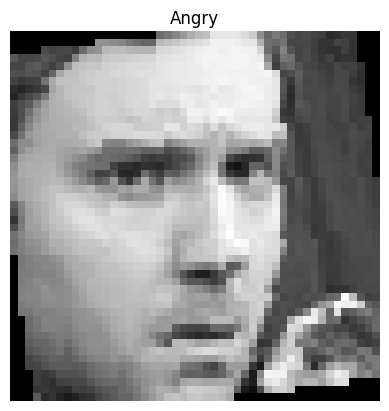

In [8]:
# Plot Angry image
hf.plot_image(img=X,
              class_names=class_names,
              label=y,
              cmap="gray",
              axis_state=False)

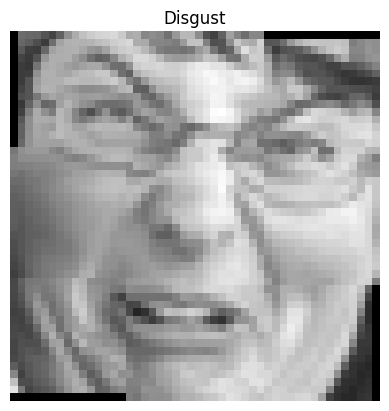

In [9]:
# Plot Disgust image
X_disgust, y_disgust = train_data[299]
hf.plot_image(img=X_disgust,
              class_names=class_names,
              label=y_disgust,
              cmap="gray",
              axis_state=False)


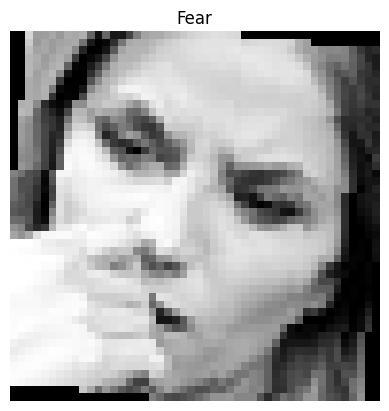

In [10]:
# Plot Fear image
X_fear, y_fear = train_data[2]
hf.plot_image(img=X_fear,
              class_names=class_names,
              label=y_fear,
              cmap="gray",
              axis_state=False)

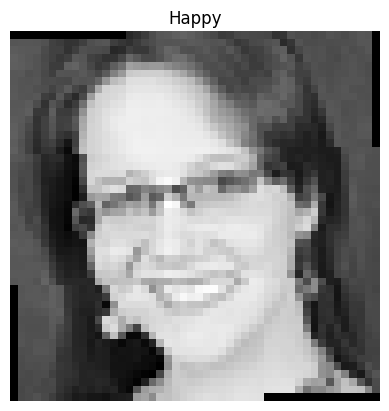

In [11]:
# Plot Happy image
X_happy, y_happy = train_data[7]
hf.plot_image(img=X_happy,
              class_names=class_names,
              label=y_happy,
              cmap="gray",
              axis_state=False)

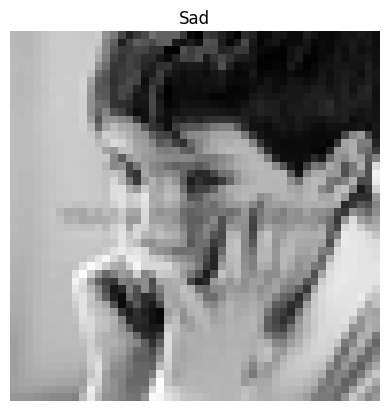

In [12]:
# Plot Sad image
X_sad, y_sad = train_data[3]
hf.plot_image(img=X_sad,
              class_names=class_names,
              label=y_sad,
              cmap="gray",
              axis_state=False)

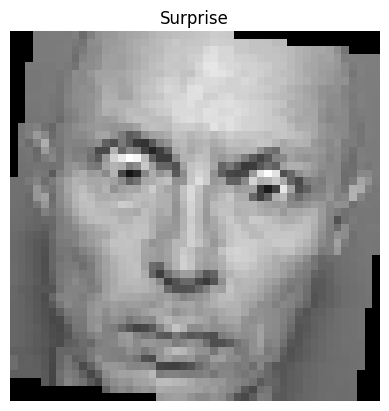

In [13]:
# Plot Surprise image
X_surprise, y_surprise = train_data[15]
hf.plot_image(img=X_surprise,
              class_names=class_names,
              label=y_surprise,
              cmap="gray",
              axis_state=False)

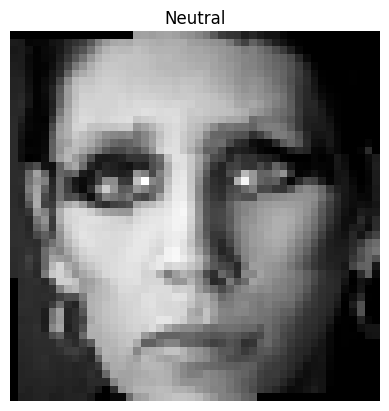

In [14]:
# Plot neutral image
X_neutral, y_neutral = train_data[4]
hf.plot_image(img=X_neutral,
              class_names=class_names,
              label=y_neutral,
              cmap="gray",
              axis_state=False)

## Model -- Self-Made

In [15]:
class FER2013V1(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units * 4, 3, 1, 1), # kernel_size=3, stride=1, padding=1
            nn.BatchNorm2d(hidden_units * 4),
            nn.GELU(),
            nn.Conv2d(hidden_units * 4, hidden_units * 4, 3, 1, 1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.GELU(),
            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units * 4, hidden_units * 2, 3, 1, 1),  # kernel_size=3, stride=1, padding=1
            nn.BatchNorm2d(hidden_units * 2),
            nn.GELU(),
            nn.Conv2d(hidden_units * 2, hidden_units * 2, 3, 1, 1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.GELU(),
            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units * 2, hidden_units, 3, 1, 1),  # kernel_size=3, stride=1, padding=1
            nn.BatchNorm2d(hidden_units),
            nn.GELU(),
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.BatchNorm2d(hidden_units),
            nn.GELU(),
            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(hidden_units * 6 * 6, hidden_units),  # conv layers don't change shape as of now, and 3 maxpools mean 48/(2^3) = 6
            nn.GELU(),
            nn.Dropout(p=0.25),
            nn.Linear(hidden_units, hidden_units),
            nn.GELU(),
            nn.Linear(hidden_units, output_shape)
        )
    
    def forward(self, X):
        return self.classifier(self.conv_block_3(self.conv_block_2(self.conv_block_1(X))))

In [16]:
'''class FER2013V1(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, 1, 1), # kernel_size=3, stride=1, padding=1
            nn.BatchNorm2d(hidden_units),
            nn.GELU(),
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.BatchNorm2d(hidden_units),
            nn.GELU(),
            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2
        )

        # Double hidden_units — double the depth, half the resolution
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units * 2, 3, 1, 1),  # kernel_size=3, stride=1, padding=1
            nn.BatchNorm2d(hidden_units * 2),
            nn.GELU(),
            nn.Conv2d(hidden_units * 2, hidden_units * 2, 3, 1, 1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.GELU(),
            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2
        )

        # Double hidden_units again
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units * 2, hidden_units * 4, 3, 1, 1),  # kernel_size=3, stride=1, padding=1
            nn.BatchNorm2d(hidden_units * 4),
            nn.GELU(),
            nn.Conv2d(hidden_units * 4, hidden_units * 4, 3, 1, 1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.GELU(),
            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            # hidden units are now 4x
            nn.Linear(hidden_units * 4 * 6 * 6, hidden_units * 2),  # conv layers don't change shape as of now, and 3 maxpools mean 48/(2^3) = 6
            nn.GELU(),
            nn.Dropout(p=0.25),
            nn.Linear(hidden_units * 2, hidden_units * 2),
            nn.GELU(),
            nn.Linear(hidden_units * 2, output_shape)
        )
    
    def forward(self, X):
        return self.classifier(self.conv_block_3(self.conv_block_2(self.conv_block_1(X))))'''

"class FER2013V1(nn.Module):\n    def __init__(self,\n                 input_shape: int,\n                 hidden_units: int,\n                 output_shape: int):\n        super().__init__()\n\n        self.conv_block_1 = nn.Sequential(\n            nn.Conv2d(input_shape, hidden_units, 3, 1, 1), # kernel_size=3, stride=1, padding=1\n            nn.BatchNorm2d(hidden_units),\n            nn.GELU(),\n            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),\n            nn.BatchNorm2d(hidden_units),\n            nn.GELU(),\n            nn.MaxPool2d(2, 2) # kernel_size=2, stride=2\n        )\n\n        # Double hidden_units — double the depth, half the resolution\n        self.conv_block_2 = nn.Sequential(\n            nn.Conv2d(hidden_units, hidden_units * 2, 3, 1, 1),  # kernel_size=3, stride=1, padding=1\n            nn.BatchNorm2d(hidden_units * 2),\n            nn.GELU(),\n            nn.Conv2d(hidden_units * 2, hidden_units * 2, 3, 1, 1),\n            nn.BatchNorm2d(hidden_units 

In [17]:
hf.set_seeds(42)
fer2013_model_one = FER2013V1(1, 64, len(class_names)).to(device) # 64 neurons
optimizer_model_one = torch.optim.AdamW(params=fer2013_model_one.parameters(), lr=0.001, weight_decay=1e-2)
loss_fn_model_one = nn.CrossEntropyLoss()
NUM_EPOCHS_MODEL_ONE = 50

[INFO] All seeds set to: 42


In [18]:
summary(fer2013_model_one, input_size=(32, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
FER2013V1                                [32, 7]                   --
├─Sequential: 1-1                        [32, 256, 24, 24]         --
│    └─Conv2d: 2-1                       [32, 256, 48, 48]         2,560
│    └─BatchNorm2d: 2-2                  [32, 256, 48, 48]         512
│    └─GELU: 2-3                         [32, 256, 48, 48]         --
│    └─Conv2d: 2-4                       [32, 256, 48, 48]         590,080
│    └─BatchNorm2d: 2-5                  [32, 256, 48, 48]         512
│    └─GELU: 2-6                         [32, 256, 48, 48]         --
│    └─MaxPool2d: 2-7                    [32, 256, 24, 24]         --
├─Sequential: 1-2                        [32, 128, 12, 12]         --
│    └─Conv2d: 2-8                       [32, 128, 24, 24]         295,040
│    └─BatchNorm2d: 2-9                  [32, 128, 24, 24]         256
│    └─GELU: 2-10                        [32, 128, 24, 24]         --

In [19]:
# Train
hf.set_seeds(42)
start_time = timer()
fer2013_model_one_writer = hf.create_writer(experiment_name="fer2013_models",
                                model_name="self_made_model")
fer2013_model_one_results = hf.train(model=fer2013_model_one,
                                     train_dataloader=train_dataloader,
                                     test_dataloader=test_dataloader,
                                     optimizer=optimizer_model_one,
                                     loss_fn=loss_fn_model_one,
                                     epochs=NUM_EPOCHS_MODEL_ONE,
                                     writer=fer2013_model_one_writer,
                                     device=device)
end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds")

[INFO] All seeds set to: 42
[INFO] Created SummaryWriter, saving to: runs/2026-05-14/fer2013_models/self_made_model...
[INFO] Setting up Cloudflare tunnel for TensorBoard...
[INFO] Downloading cloudflared binary...
[INFO] TensorBoard started at http://localhost:6008

TENSORBOARD PUBLIC URL: trycloudflare.com...

[INFO] Model graph traced with input shape: torch.Size([32, 1, 48, 48])


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.7286 | train_acc: 0.3104 | test_loss: 1.4986 | test_acc: 0.4208
[INFO] Saved new best model to checkpoints/best_accuracy_model.pth | best_metric: 0.4208
Epoch: 2 | train_loss: 1.4645 | train_acc: 0.4371 | test_loss: 1.3292 | test_acc: 0.4924
[INFO] Saved new best model to checkpoints/best_accuracy_model.pth | best_metric: 0.4924


: 

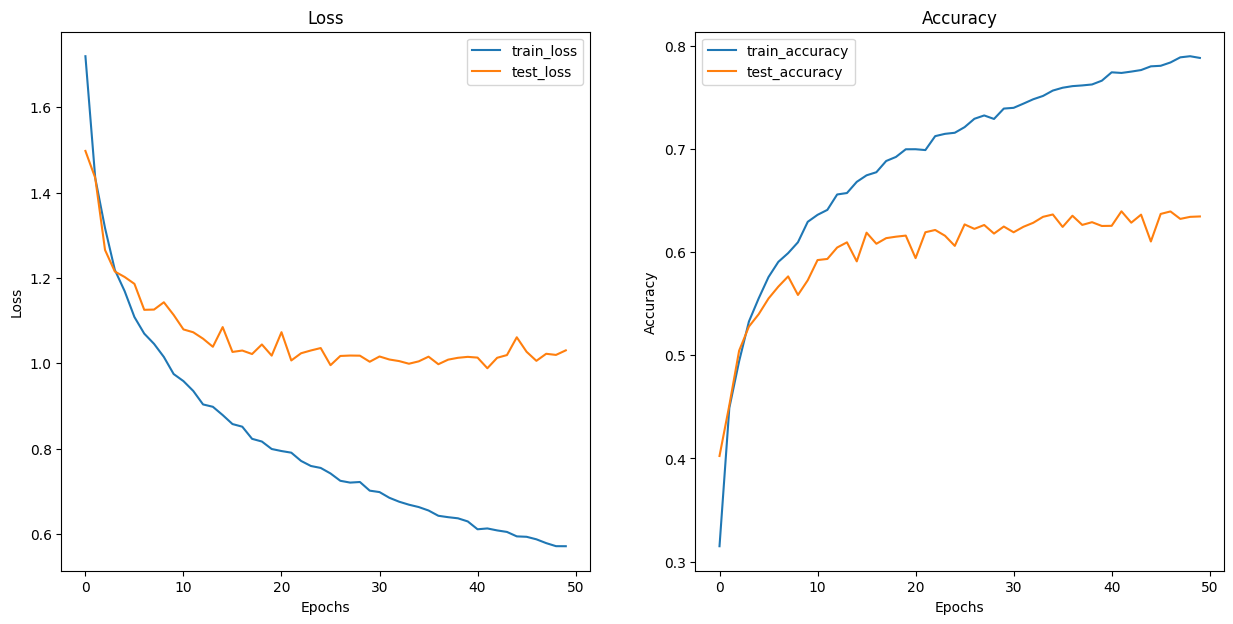

In [ ]:
hf.plot_loss_curves(fer2013_model_one_results)

To reduce overfitting
* higher dropout probability + lower number of neurons - failed
* data augmentation - failed
* retry data augmentation, but without vertical flip and with 50 epochs. - a bit better but still failure
From ^ onwards, 50 epochs:
* decrease # hidden units going on - a bit better but not that good
* learning rate decay
* different optimizer
* remove gradient clipping

## Model -- Transfer Learning

to do:
* decrease # of hidden units
* do a vgg16 transfer learning
* if that fails, try resnet 50

Need to run the data setup and imports above for this

In [ ]:
model_weights = torchvision.models.VGG16_BN_Weights.DEFAULT
auto_transforms = model_weights.transforms()

tl_train_data = datasets.FER2013(root="data",
                                 split="train",
                                 transform=auto_transforms)
tl_test_data = datasets.FER2013(root="data",
                                 split="test",
                                 transform=auto_transforms)

tl_train_dataloader = DataLoader(dataset=tl_train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False, # Sampler does shuffling
                              sampler=sampler)

tl_test_dataloader = DataLoader(dataset=tl_test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

In [ ]:
fer2013_model_two = torchvision.models.vgg16_bn(weights=model_weights).to(device)
summary(model=fer2013_model_two, 
        input_size=(32, 3, 224, 224),
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
VGG (VGG)                                [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                  [32, 3, 224, 224]    [32, 512, 7, 7]      --                   True
│    └─Conv2d (0)                        [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
│    └─BatchNorm2d (1)                   [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
│    └─ReLU (2)                          [32, 64, 224, 224]   [32, 64, 224, 224]   --                   --
│    └─Conv2d (3)                        [32, 64, 224, 224]   [32, 64, 224, 224]   36,928               True
│    └─BatchNorm2d (4)                   [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
│    └─ReLU (5)                          [32, 64, 224, 224]   [32, 64, 224, 224]   --                   --
│    └─MaxPool2d (

In [ ]:
for param in fer2013_model_two.features.parameters():
    param.requires_grad = False

summary(model=fer2013_model_two, 
        input_size=(32, 3, 224, 224),
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
VGG (VGG)                                [32, 3, 224, 224]    [32, 1000]           --                   Partial
├─Sequential (features)                  [32, 3, 224, 224]    [32, 512, 7, 7]      --                   False
│    └─Conv2d (0)                        [32, 3, 224, 224]    [32, 64, 224, 224]   (1,792)              False
│    └─BatchNorm2d (1)                   [32, 64, 224, 224]   [32, 64, 224, 224]   (128)                False
│    └─ReLU (2)                          [32, 64, 224, 224]   [32, 64, 224, 224]   --                   --
│    └─Conv2d (3)                        [32, 64, 224, 224]   [32, 64, 224, 224]   (36,928)             False
│    └─BatchNorm2d (4)                   [32, 64, 224, 224]   [32, 64, 224, 224]   (128)                False
│    └─ReLU (5)                          [32, 64, 224, 224]   [32, 64, 224, 224]   --                   --
│    └─Max

In [ ]:
n_inputs = fer2013_model_two.classifier[0].in_features
fer2013_model_two.classifier = nn.Sequential(
    nn.Linear(n_inputs, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.3),
    nn.Linear(256, 7) # 7 classes for FER2013
)
summary(model=fer2013_model_two, 
        input_size=(32, 3, 224, 224),
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
VGG (VGG)                                [32, 3, 224, 224]    [32, 7]              --                   Partial
├─Sequential (features)                  [32, 3, 224, 224]    [32, 512, 7, 7]      --                   False
│    └─Conv2d (0)                        [32, 3, 224, 224]    [32, 64, 224, 224]   (1,792)              False
│    └─BatchNorm2d (1)                   [32, 64, 224, 224]   [32, 64, 224, 224]   (128)                False
│    └─ReLU (2)                          [32, 64, 224, 224]   [32, 64, 224, 224]   --                   --
│    └─Conv2d (3)                        [32, 64, 224, 224]   [32, 64, 224, 224]   (36,928)             False
│    └─BatchNorm2d (4)                   [32, 64, 224, 224]   [32, 64, 224, 224]   (128)                False
│    └─ReLU (5)                          [32, 64, 224, 224]   [32, 64, 224, 224]   --                   --
│    └─Max

In [ ]:
tl_loss_fn = nn.CrossEntropyLoss(weight=weights)
tl_optimizer = torch.optim.AdamW(params=fer2013_model_two.parameters(), lr=1e-4)

scheduler = ReduceLROnPlateau(
    tl_optimizer, 
    mode='min', 
    factor=0.1, 
    patience=5,
)

In [ ]:
# Train
hf.set_seeds(42)
tl_start_time = timer()
fer2013_model_two_writer = hf.create_writer(experiment_name="fer2013_models",
                                model_name="tl_model")
fer2013_model_two_results = hf.train(model=fer2013_model_two,
                                     train_dataloader=tl_train_dataloader,
                                     test_dataloader=tl_test_dataloader,
                                     optimizer=tl_optimizer,
                                     loss_fn=tl_loss_fn,
                                     epochs=NUM_EPOCHS_MODEL_ONE,
                                     writer=fer2013_model_two_writer,
                                     device=device,
                                     scheduler=scheduler)
tl_end_time = timer()
print(f"Total training time: {tl_end_time - tl_start_time:.3f} seconds")

[INFO] All seeds set to: 42
[INFO] Created SummaryWriter, saving to: runs/2026-05-14/fer2013_models/tl_model...


TypeError: train() got an unexpected keyword argument 'scheduler'